In [52]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 라이브러리 버젼 체크 : 충돌방지

In [17]:
import sklearn
sklearn.__version__

'1.7.1'

In [15]:
import pandas as pd
pd.__version__

'2.3.0'

# 데이터 체크

In [53]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df

,나이,회사와의마찰,출장,일당,부서,거리,학력,전공,사번,만족도,...,성인여부,야근,업무평가,주변평가,근무기준시간,스톡옵션레벨,경력,전년도교육출장횟수,워라밸,현회사근속년수
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,Y,Yes,3,1,80,0,8,0,1,6
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,Y,No,4,4,80,1,10,3,3,10
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,Y,Yes,3,2,80,0,7,3,3,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,Y,Yes,3,3,80,0,8,3,3,8
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,Y,No,3,4,80,1,6,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,Y,No,3,3,80,1,17,3,3,5
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,Y,No,3,1,80,1,9,5,3,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,Y,Yes,4,2,80,1,6,0,3,6
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,Y,No,3,4,80,0,17,3,2,9


In [54]:
df[df.isna().any(axis=1)] # 결측치 0건

,나이,회사와의마찰,출장,일당,부서,거리,학력,전공,사번,만족도,...,성인여부,야근,업무평가,주변평가,근무기준시간,스톡옵션레벨,경력,전년도교육출장횟수,워라밸,현회사근속년수


In [55]:
df.columns

Index(['나이', '회사와의마찰', '출장', '일당', '부서', '거리', '학력', '전공', '사번', '만족도', '성별',
       '시급', '참여프로젝트', '근속연차', '직급', '직업만족도', '결혼여부', '월급', '이직회수', '성인여부',
       '야근', '업무평가', '주변평가', '근무기준시간', '스톡옵션레벨', '경력', '전년도교육출장횟수', '워라밸',
       '현회사근속년수'],
      dtype='object')

In [56]:
x_col = ['나이','출장','부서','학력','전공','참여프로젝트','직급','경력','전년도교육출장횟수','현회사근속년수']
y_col = ['업무평가']

# 독립변수 데이터 분포 점검
- 데이터의 형태가 심각하게 비정규성을 띄고
- 샘플 모델의 accuracy가 너무 낮다면
- 스케일링 통해 분포를 맞출 필요
- 또한 feature importance가 낮은데 불균등 분포여도 feature 제거 고려

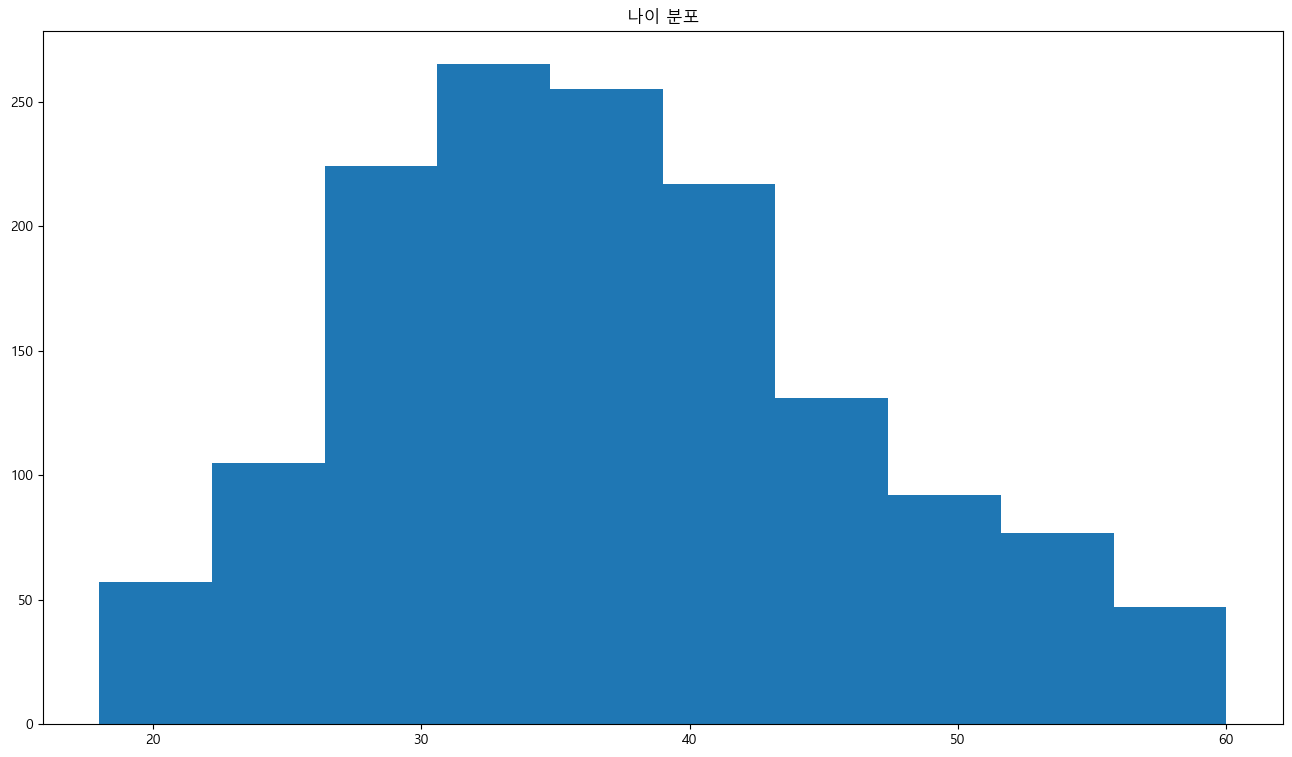

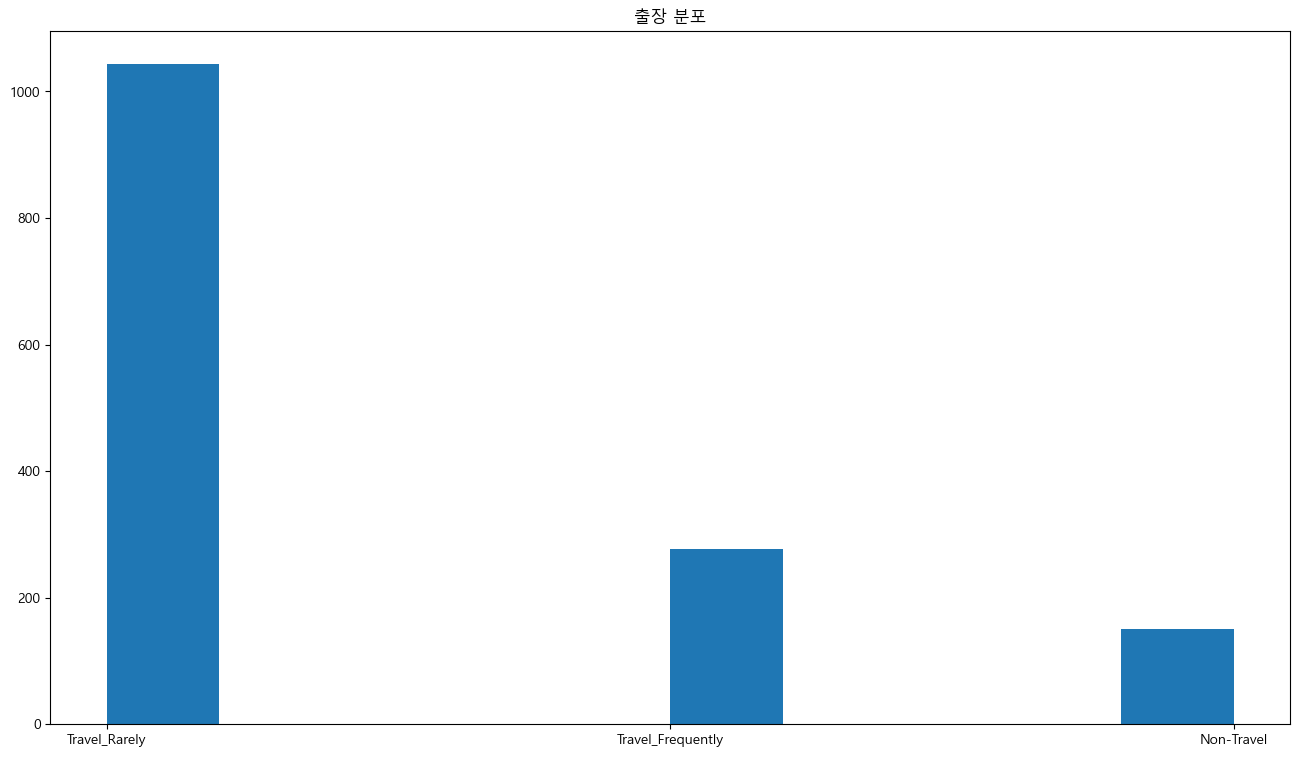

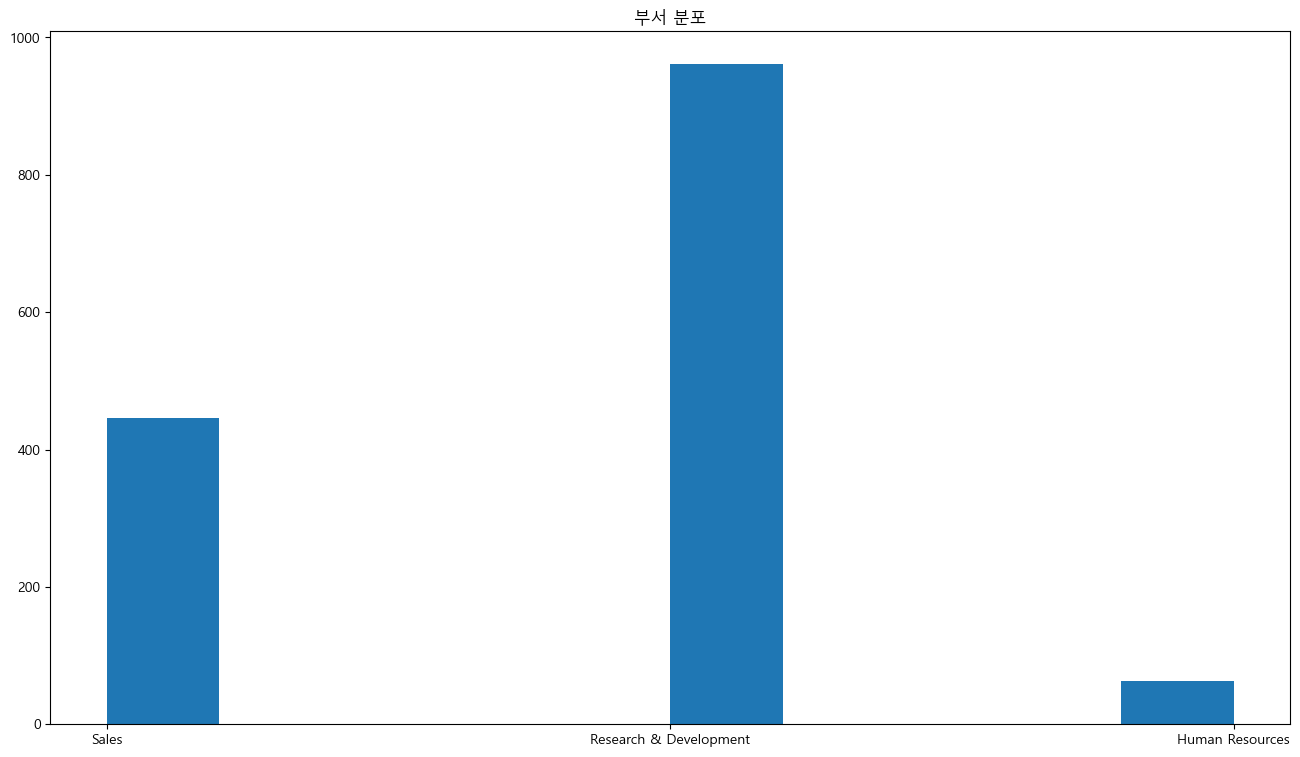

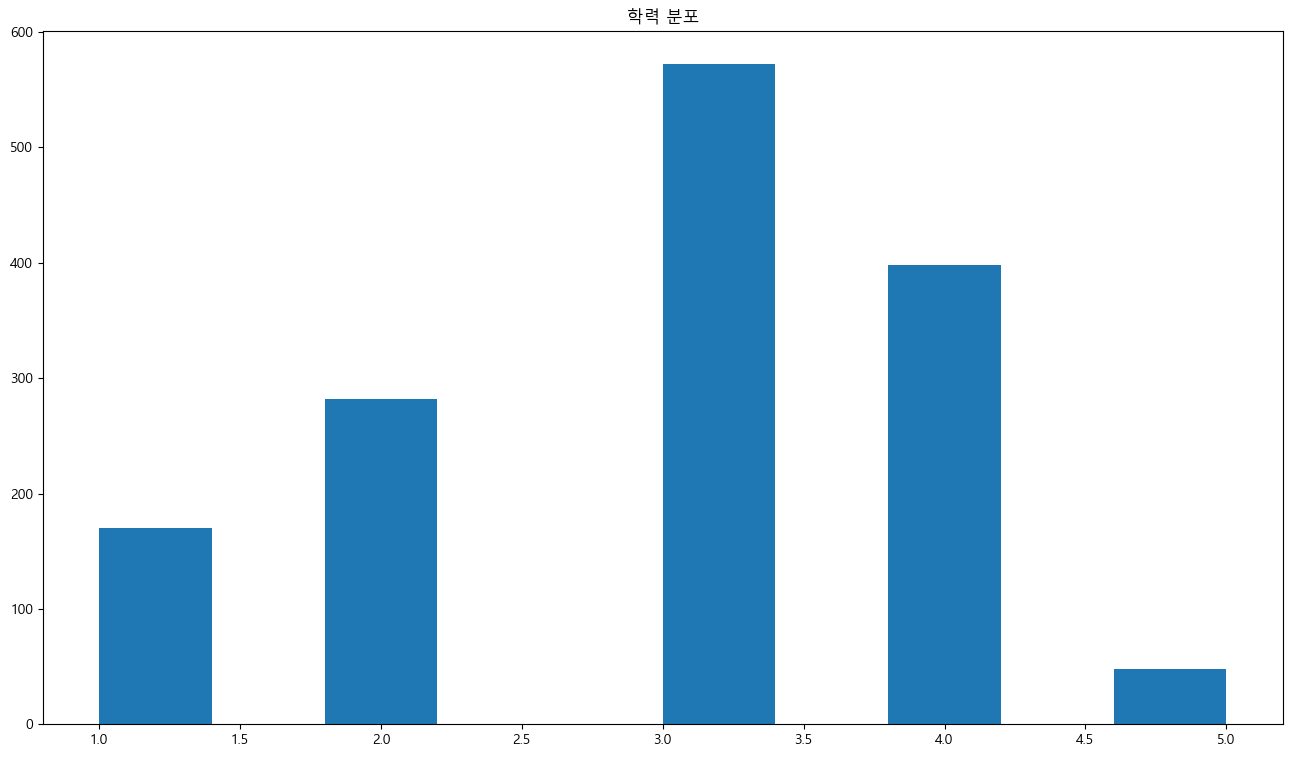

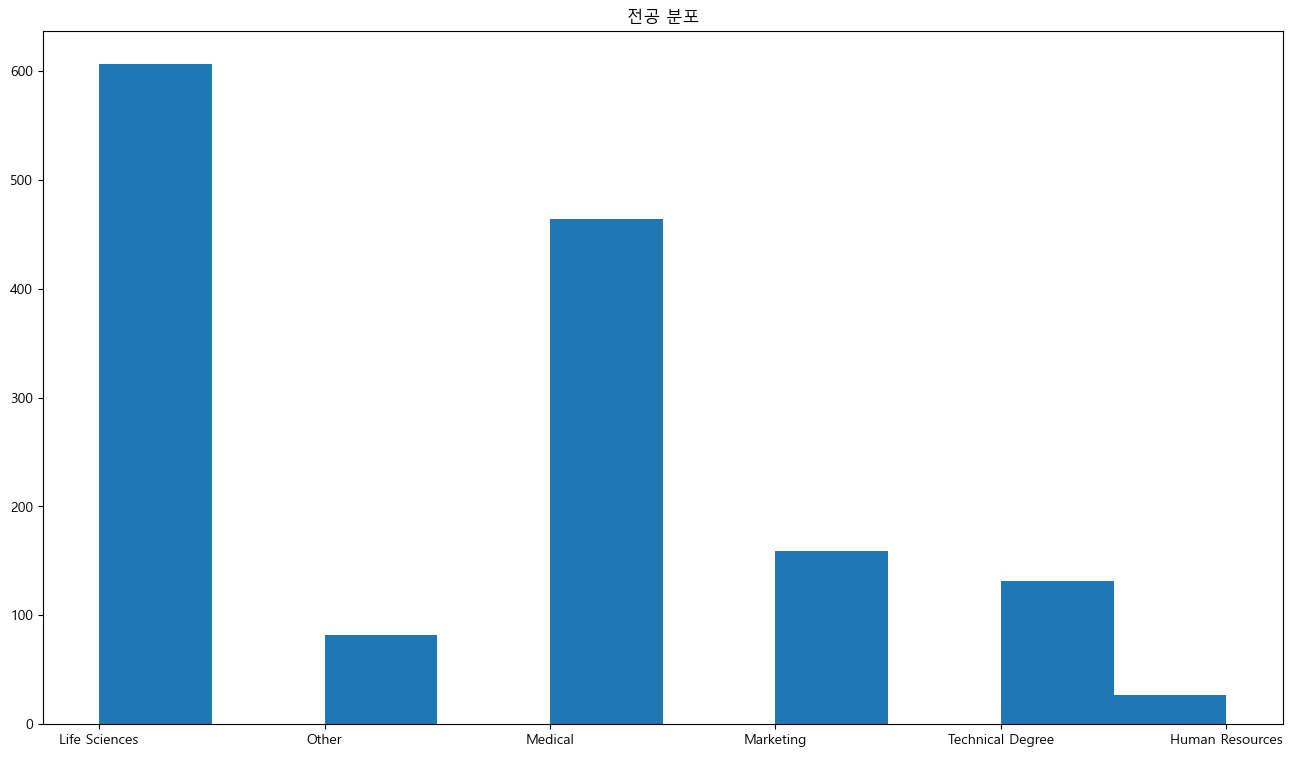

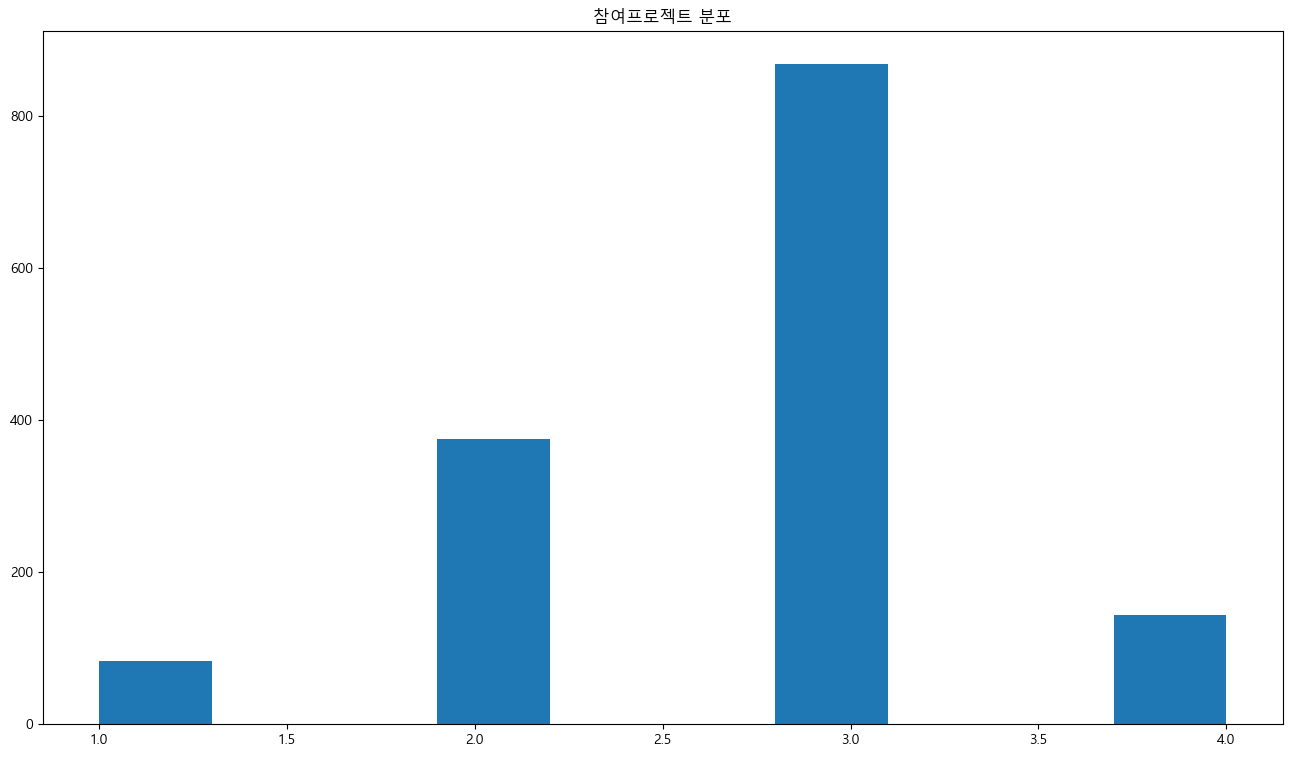

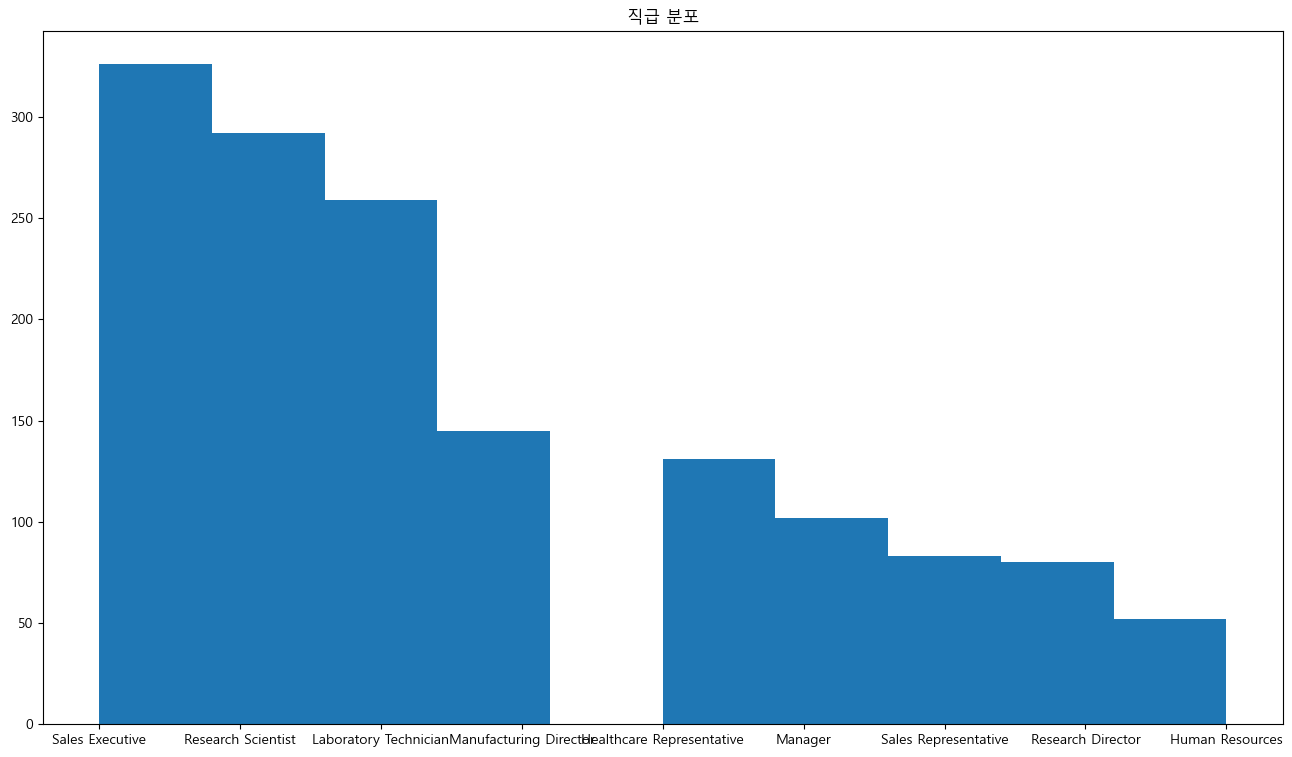

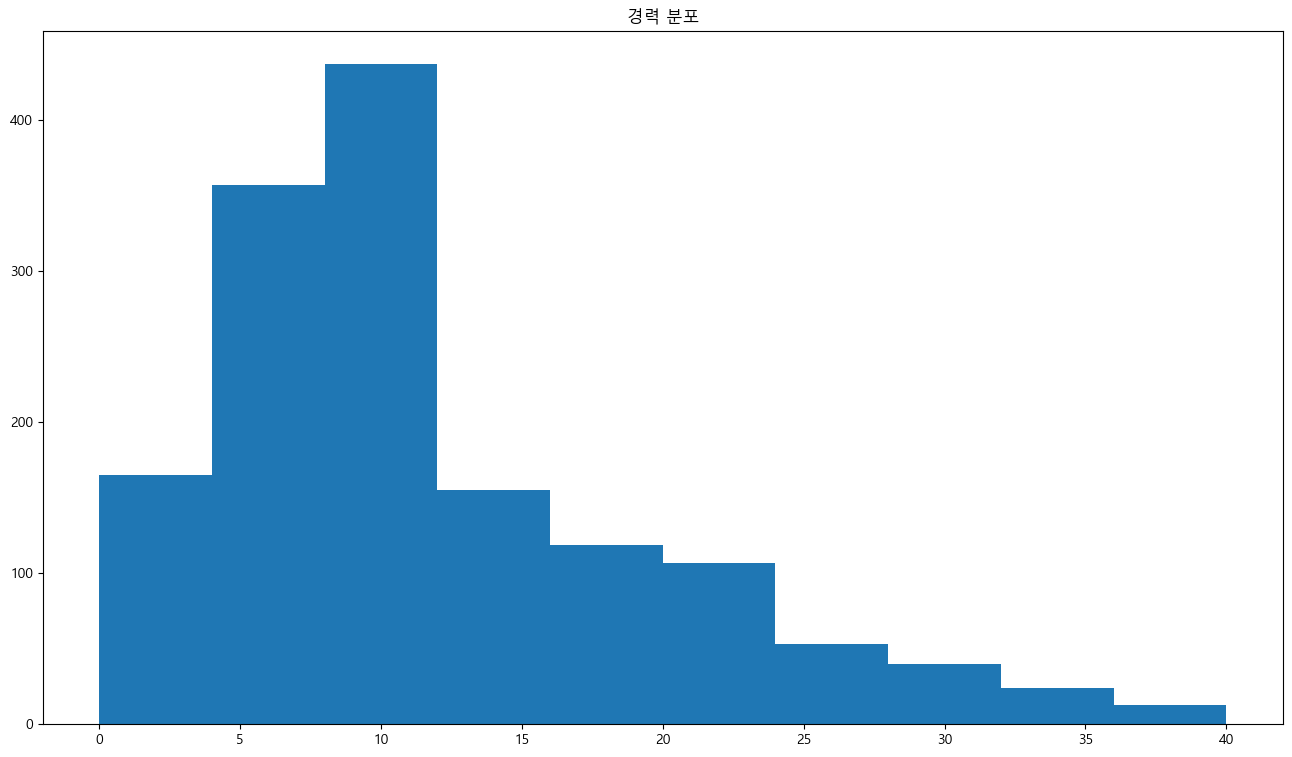

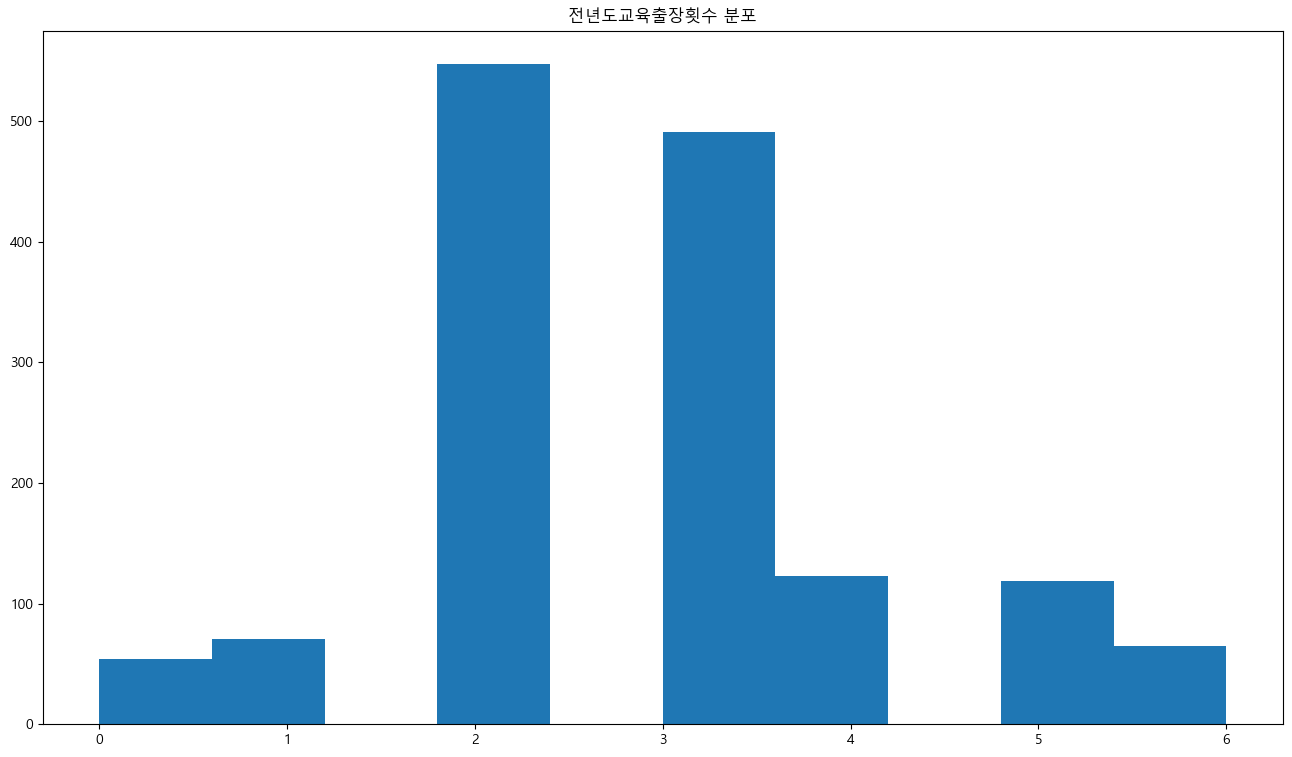

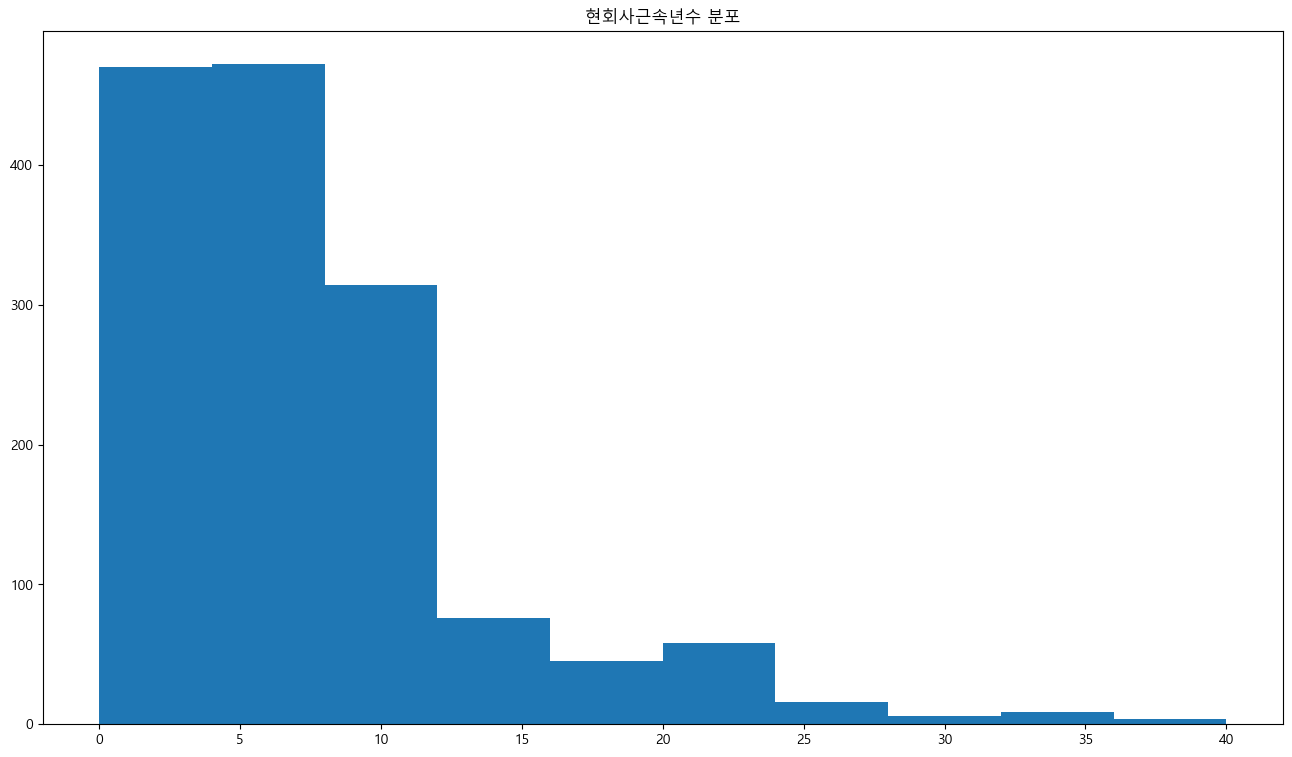

In [57]:
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
for col in x_col :
    plt.figure(figsize=(16,9))
    plt.hist(df[col])
    plt.title(f"{col} 분포")
#     print(df[col].value_counts()) # 데이터 분포가 비정상적


# 타겟변수 분포 점검

In [112]:
df['업무평가'].value_counts()

업무평가
3    1244
4     226
Name: count, dtype: int64

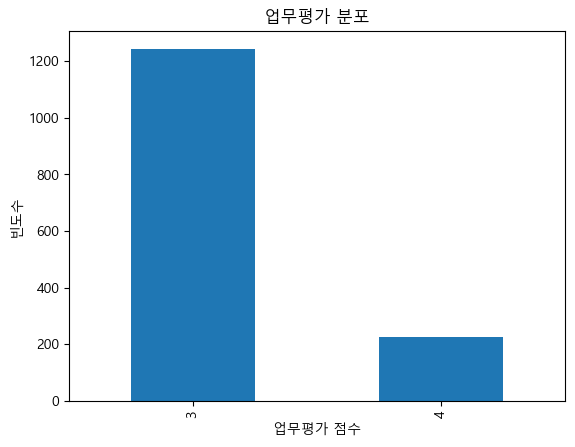

In [117]:
df['업무평가'].value_counts().sort_index().plot(kind='bar')
plt.title("업무평가 분포")
plt.xlabel("업무평가 점수")
plt.ylabel("빈도수")
plt.show()

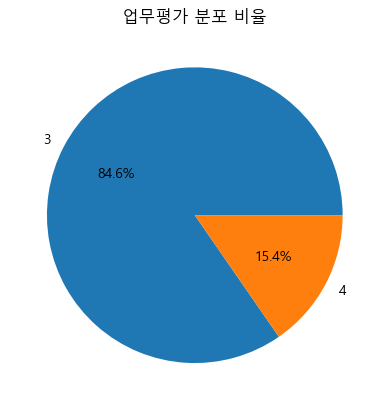

In [118]:
df['업무평가'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title("업무평가 분포 비율")
plt.ylabel("")  # y축 라벨 제거
plt.show()

타겟변수의 분포가 불균등하여 원하는 결과가 도출되지 않으면 
- 데이터 추가 확보 : 불가능
- class_weight를 조정하거나
- smote 등
데이터를 강화해야함

# 데이터 전처리

In [119]:
# 데이터 우선 재체크
df_data = df[x_col + y_col]
df_data

,나이,출장,부서,학력,전공,참여프로젝트,직급,경력,전년도교육출장횟수,현회사근속년수,업무평가
0,41,Travel_Rarely,Sales,2,Life Sciences,3,Sales Executive,8,0,6,3
1,49,Travel_Frequently,Research & Development,1,Life Sciences,2,Research Scientist,10,3,10,4
2,37,Travel_Rarely,Research & Development,2,Other,2,Laboratory Technician,7,3,0,3
3,33,Travel_Frequently,Research & Development,4,Life Sciences,3,Research Scientist,8,3,8,3
4,27,Travel_Rarely,Research & Development,1,Medical,3,Laboratory Technician,6,3,2,3
...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,Research & Development,2,Medical,4,Laboratory Technician,17,3,5,3
1466,39,Travel_Rarely,Research & Development,1,Medical,2,Healthcare Representative,9,5,7,3
1467,27,Travel_Rarely,Research & Development,3,Life Sciences,4,Manufacturing Director,6,0,6,4
1468,49,Travel_Frequently,Sales,3,Medical,2,Sales Executive,17,3,9,3


In [36]:
# 학습셋, 시험셋 분리
from sklearn.model_selection import train_test_split
x = df_data[x_col]
y = df_data[y_col]
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size=0.2,stratify=y)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1176, 10), (294, 10), (1176, 1), (294, 1))

## 데이터 처리 방안 토의 필요점

In [24]:
df['출장'].unique() # 출장 : 빈도 정도를 선택해야함 => 설정필요(안갔다 0 ~ 2회 적게 3 ~ 5회 자주 갔다 6 ~ 이상 등)

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object)

In [25]:
df['부서'].unique() # 부서 재설정??

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [27]:
df['전공'].unique() # 전공도 좀 수정할 필요가 있으려나?

array(['Life Sciences', 'Other', 'Medical', 'Marketing',
       'Technical Degree', 'Human Resources'], dtype=object)

In [29]:
df['직급'].unique() # 한국에 맞춰서 사원 - 대리 - 과장 - 팀장 - 부장 - 사장... 등으로 분할 필요

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

## 우선 데이터 셋 그대로 진행

In [38]:
from sklearn.preprocessing import LabelEncoder
le_buisness = LabelEncoder() # 출장
le_depart = LabelEncoder() # 부서
le_major = LabelEncoder() # 전공
le_manager = LabelEncoder() # 직금

In [39]:
X_train['출장'] = le_buisness.fit_transform(X_train['출장'])
X_train['부서'] = le_depart.fit_transform(X_train['부서'])
X_train['전공'] = le_major.fit_transform(X_train['전공'])
X_train['직급'] = le_manager.fit_transform(X_train['직급'])

In [41]:
X_train.info() # ok

<class 'pandas.core.frame.DataFrame'>
Index: 1176 entries, 1262 to 380
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   나이         1176 non-null   int64
 1   출장         1176 non-null   int64
 2   부서         1176 non-null   int64
 3   학력         1176 non-null   int64
 4   전공         1176 non-null   int64
 5   참여프로젝트     1176 non-null   int64
 6   직급         1176 non-null   int64
 7   경력         1176 non-null   int64
 8   전년도교육출장횟수  1176 non-null   int64
 9   현회사근속년수    1176 non-null   int64
dtypes: int64(10)
memory usage: 101.1 KB


In [42]:
X_test['출장'] = le_buisness.fit_transform(X_test['출장'])
X_test['부서'] = le_depart.fit_transform(X_test['부서'])
X_test['전공'] = le_major.fit_transform(X_test['전공'])
X_test['직급'] = le_manager.fit_transform(X_test['직급'])

In [43]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 383 to 775
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   나이         294 non-null    int64
 1   출장         294 non-null    int64
 2   부서         294 non-null    int64
 3   학력         294 non-null    int64
 4   전공         294 non-null    int64
 5   참여프로젝트     294 non-null    int64
 6   직급         294 non-null    int64
 7   경력         294 non-null    int64
 8   전년도교육출장횟수  294 non-null    int64
 9   현회사근속년수    294 non-null    int64
dtypes: int64(10)
memory usage: 25.3 KB


# sample 모델 : RandomForeseClassifier
- RandomForestClassifier로 우선 sampling 후 feature_importance_ 점검
- 이후 class_weight = "balanced" 점검
- 결과에 따라 타 모델 점검 및 smote 여부 점검

In [63]:
np.array(X_train)

array([[43,  1,  1, ...,  6,  4,  1],
       [34,  2,  2, ...,  8,  2,  8],
       [52,  2,  1, ...,  6,  3,  2],
       ...,
       [34,  0,  2, ...,  6,  3,  3],
       [32,  1,  1, ..., 10,  3,  5],
       [24,  2,  2, ...,  5,  2,  5]], shape=(1176, 10))

In [65]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
rf_model = RandomForestClassifier()
history = rf_model.fit(np.array(X_train), np.array(Y_train).ravel())

In [66]:
history

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
# rf_model.feature_importances_
# X_train.columns

features = pd.DataFrame(np.c_[X_train.columns,rf_model.feature_importances_], columns=['feature_name','feature_importance'])
features

,feature_name,feature_importance
0,나이,0.191581
1,출장,0.047565
2,부서,0.027082
3,학력,0.084783
4,전공,0.072164
5,참여프로젝트,0.071834
6,직급,0.093732
7,경력,0.158367
8,전년도교육출장횟수,0.099669
9,현회사근속년수,0.153223


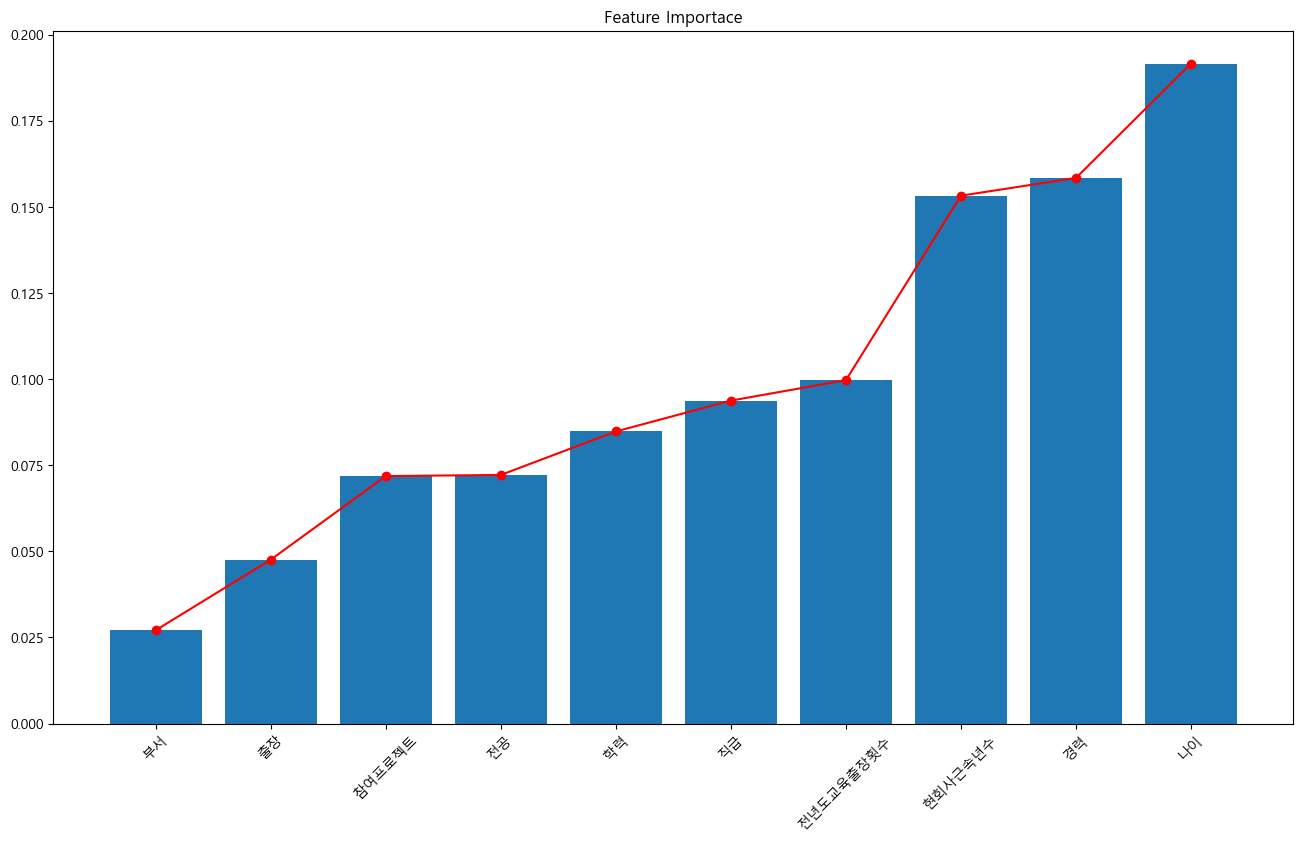

In [86]:
features.sort_values(by=['feature_importance'], ascending=True, inplace=True)
plt.figure(figsize=(16,9))
plt.plot(features.feature_name,features.feature_importance, color='red', marker='o')
plt.bar(features.feature_name,features.feature_importance)
plt.xticks(rotation=45)
plt.title("Feature Importace")
plt.show()

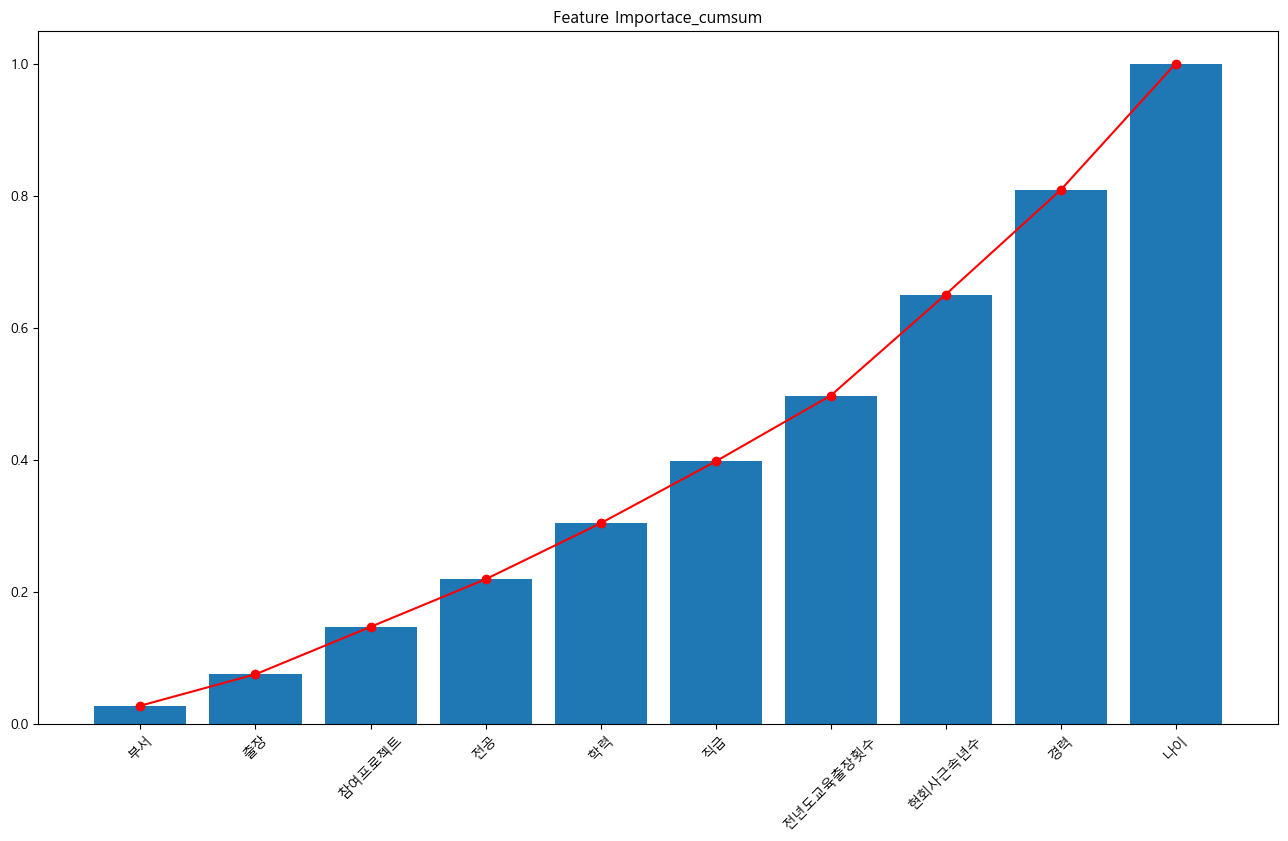

In [88]:
feature_y = np.cumsum(features.feature_importance)
# feature_y
features.sort_values(by=['feature_importance'], ascending=True, inplace=True)
plt.figure(figsize=(16,9))
plt.plot(features.feature_name,feature_y, color='red', marker='o')
plt.bar(features.feature_name,feature_y)
plt.xticks(rotation=45)
plt.title("Feature Importace_cumsum")
plt.show()

# feature_importance_ 확인 결과
1. cumsum 그래프가 꾸준히 상승하는 형태 : feature 종류의 부족일 수도
2. accuracy를 체크 후 모델 개선 방향 탐색

In [93]:
pred = rf_model.predict(np.array(X_test))
value = np.array(Y_test).ravel()

In [99]:
pred.shape, value.shape

((294,), (294,))

In [103]:
pd.crosstab(value,pred, rownames=['실제값'],colnames=['예측값'])

예측값,3,4
실제값,,
3,244,5
4,45,0
